<a href="https://colab.research.google.com/github/Eng-Emmy/CNN-SINIFLANDIRMA/blob/main/model1_Transfer_VGG16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **UYGULAMA:Transfer Learning with Fine Tuning/ 1. PROJE**

* Adınız: **Emmanuel**
* Soyadınız:  **HAKIRUWIZERA**
* Okul Numaranız: **2440631002**
* GitHub Repo Bağlantısı:

# **GİRİŞ**

Bu proje, elma ve portakal sınıflarına ait özel bir veri kümesi kullanılarak görüntü sınıflandırması için Evrişimli Sinir Ağı (CNN) modellerinin oluşturulması ve değerlendirilmesine odaklanmaktadır.
Toplamda 400 görüntü, özgünlük sağlamak amacıyla cep telefonu kamerası ile çekilmiştir.
Veri kümesi,

320 görüntü (%80) → Eğitim
40 görüntü (%10) → Doğrulama
40 görüntü (%10) → Test
olmak üzere üçe ayrılmıştır.


Projenin amacı, Model 1 kapsamında VGG16 gibi güncel mimarilerle transfer öğrenme yöntemini uygulamaktır.
Modelin geliştirilmesinde Keras kütüphanesi kullanılmış olup, performans değerlendirmesi;


Eğitim ve doğrulama sürecinde elde edilen doğruluk ve kayıp grafikleri,
Test doğruluğu raporlaması üzerinden gerçekleştirilmiştir.


### **İçe Aktarılan Kütüphanelerin Özeti ve Amaçları**

- **keras.preprocessing.image & tensorflow.keras.preprocessing.image.ImageDataGenerator**  
  Görsellerin yüklenmesi, ön işlenmesi ve veri artırma (data augmentation) tekniklerinin uygulanması için kullanılır.

- **keras.layers (Dense, Flatten, Dropout, BatchNormalization)**  
  Sinir ağı katmanlarını oluşturmak için temel yapı taşları:
  - `Dense`: Tam bağlı (fully connected) katman.
  - `Flatten`: 2D özellik haritalarını 1D vektöre dönüştürür.
  - `Dropout`: Aşırı öğrenmeyi (overfitting) azaltmak için rastgele nöronları devre dışı bırakır.
  - `BatchNormalization`: Aktivasyonları normalize ederek eğitimi hızlandırır.

- **tensorflow.keras.callbacks.ModelCheckpoint**  
  Eğitim sırasında doğrulama performansına göre en iyi modeli kaydeder.

- **keras.metrics.categorical_crossentropy**  
  Çok sınıflı sınıflandırma görevleri için kullanılan kayıp fonksiyonu.

- **keras.applications.imagenet_utils & keras.applications.vgg16**  
  Transfer öğrenme için yardımcı araçlar ve önceden eğitilmiş modeller (ör. VGG16) sağlar.

- **keras.applications.vgg16.preprocess_input**  
  VGG16 için giriş görsellerini ön işleme fonksiyonu.

- **sklearn.metrics.confusion_matrix**  
  Gerçek ve tahmin edilen etiketleri göstererek sınıflandırma performansını değerlendirmek için kullanılır.

- **keras.optimizers.Adam**  
  Sinir ağlarını verimli şekilde eğitmek için kullanılan optimizasyon algoritması.

- **matplotlib.pyplot**  
  Doğruluk ve kayıp grafikleri ile görselleştirmeler için kullanılır.

- **keras.models.Model**  
  Katmanları ve mimarileri birleştirerek özel modeller oluşturmayı sağlar.

- **itertools**  
  Kombinasyonlar üzerinde yineleme yapmak için kullanılır; genellikle karmaşıklık matrisleri (confusion matrix) çiziminde tercih


In [13]:

from keras.preprocessing import image
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from keras.layers import Dense, Flatten, Dropout, BatchNormalization
from tensorflow.keras.callbacks import ModelCheckpoint
from keras.metrics import categorical_crossentropy
from keras.applications import imagenet_utils
from sklearn.metrics import confusion_matrix
from keras.optimizers import Adam
from keras.applications import vgg16
from keras. applications.vgg16 import preprocess_input
import matplotlib.pyplot as plt
from keras.models import Model
import itertools

Google Colab’ı Google Drive’a bağlamak ve veri seti yollarını tanımlamak.

drive.mount('/content/drive') → Google Drive’ı Colab ortamına bağlar.

train_path, valid_path, test_path → MyDrive/Colab_CNN_Project1/Bitki/ dizininde bulunan eğitim, doğrulama ve test veri seti klasörlerinin yollarını belirler.

In [18]:
#Google Drive Bağlantısı

from google.colab import drive
drive.mount('/content/drive')

train_path = '/content/drive/MyDrive/Colab_CNN_Project1/Bitki/train'
valid_path = '/content/drive/MyDrive/Colab_CNN_Project1/Bitki/val'
test_path = '/content/drive/MyDrive/Colab_CNN_Project1/Bitki/test'


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



### **Veri Üreticisi (Data Generator) Özeti**
- **Amaç:** Eğitim, doğrulama ve test veri setlerini VGG16 için uygun şekilde hazırlamak.
- **İşlemler:**
  - Görseller **224x224** boyutuna yeniden boyutlandırılır.
  - `preprocess_input` fonksiyonu ile VGG16 ön işleme uygulanır.
- **Batch Ayarları:**
  - Eğitim: `batch_size=32`, `class_mode='categorical'`
  - Doğrulama: `batch_size=32`, `class_mode='categorical'`
  - Test: `batch_size=32`, `shuffle=False` (etiket)


In [19]:
# Data generator (şu anda sadece yeniden boyutlandırma)

train_batches = ImageDataGenerator(preprocessing_function=preprocess_input).flow_from_directory(
    train_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical' )

valid_batches = ImageDataGenerator(preprocessing_function=preprocess_input).flow_from_directory(
    valid_path,
    target_size=(224,224),
    batch_size=32,
    class_mode='categorical')

test_batches = ImageDataGenerator(preprocessing_function=preprocess_input).flow_from_directory(
    test_path,
    target_size=(224,224),
    batch_size=32,
    shuffle=False,
    class_mode='categorical')

Found 320 images belonging to 4 classes.
Found 40 images belonging to 4 classes.
Found 40 images belonging to 4 classes.


#VGG16 Modelinin Yüklenmesi
Amaç: VGG16 tabanlı bir model oluşturmak (transfer öğrenme için).
weights="imagenet" → Model, ImageNet üzerinde önceden eğitilmiş ağırlıkları kullanır.

include_top=False → VGG16’nın orijinal tam bağlı (FC) katmanları çıkarılır; sadece konvolüsyonel taban kullanılır.
input_shape=(224,224,3) → Giriş boyutu 224×224 piksel ve 3 kanal (RGB).

pooling='avg' → Çıkışta Global Average Pooling uygulanır (özellikleri tek boyuta indirger).
base_model.summary() → Modelin katman yapısını ve parametrelerini özetler.

Convolutional layers: 13
MaxPooling layers: 5
Plus: If pooling='avg' or 'max' is set, there is an additional Global Pooling layer at the end.

In [20]:
base_model = vgg16.VGG16(weights = "imagenet", include_top=False, input_shape = (224,224, 3), pooling='avg')
base_model.summary()



58889256/58889256 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 14,714,688 (56.13 MB)

 Non-trainable params: 0 (0.00 B)

#Özellik Çıkarıcı Katmanları Eğitime Kapama:
**Amaç:** Transfer öğrenme için VGG16 tabanındaki katmanların çoğunu dondurmak.
for layer in base_model.layers[:-5]: layer.trainable = False

Son 5 katman hariç tüm katmanlar eğitilemez (trainable=False) olarak ayarlanır.
Bu, önceden eğitilmiş özelliklerin korunmasını sağlar ve yalnızca üst katmanların ince ayar yapılmasına izin verir.


base_model.summary()

Modelin güncellenmiş mimarisini gösterir; hangi katmanların dondurulduğu ve hangilerinin eğitilebilir olduğu belirtilir.

In [21]:
for layer in base_model.layers[:-5]:
    layer.trainable = False
base_model.summary()

for layer in base_model.layers:
    print(layer.name, layer.trainable)
#Sonuçlardaki, True (eğitime açık) ve False (dondurulmuş)

Model: "vgg16"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,714,688 (56.13 MB)

 Trainable params: 7,079,424 (27.01 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

input_layer False
block1_conv1 False
block1_conv2 False
block1_pool False
block2_conv1 False
block2_conv2 False
block2_pool False
block3_conv1 False
block3_conv2 False
block3_conv3 False
block3_pool False
block4_conv1 False
block4_conv2 False
block4_conv3 False
block4_pool False
block5_conv1 True
block5_conv2 True
block5_conv3 True
block5_pool True
global_average_pooling2d True


#VGG16 üzerine özel bir sınıflandırıcı ekle:

GAP çıktısını giriş olarak kullan.
4 birimli + softmax aktivasyonlu Dense katmanı ekle (çok sınıflı sınıflandırma için).
Yeni model: base_model’in girdileri + eklenen katmanın çıktısı.

Neden?
Önceden eğitilmiş VGG16 modelini (ImageNet üzerinde) kendi özel görevine (4 sınıflı işaret dili sayıları) uyarlamak için. Böylece tüm ağı yeniden eğitmeye gerek kalmaz, zaman tasarrufu sağlanır ve sınırlı veriyle daha yüksek doğruluk elde edilir.


In [30]:
from tensorflow.keras.layers import Dropout
from tensorflow.keras.regularizers import l2

# use “get_layer” method to save the last layer of the network
last_layer = base_model.get_layer('global_average_pooling2d')

# save the output of the last layer to be the input of the next layer
last_output = last_layer.output

# Add a hidden Dense layer with ReLU activation and L2 regularization
x = Dense(128, activation='relu', kernel_regularizer=l2(0.001))(last_output)

x = Dropout(0.5)(x)  # 50% dropout

# Add the final softmax layer with 4 units for 4 classes
x = Dense(4, activation='softmax', name='softmax_output')(x)

# instantiate a new_model using keras’s Model class
new_model = Model(inputs=base_model.input, outputs=x, name='base_plus_head')

#yeni modelin eğitim
new_model.compile(Adam(learning_rate=0.0001),
                  loss='categorical_crossentropy',
                  metrics=['Accuracy'])

# print the new_model summary
new_model.summary()

Model: "base_plus_head"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv1 (Conv2D)           │ (None, 224, 224, 64)   │         1,792 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_conv2 (Conv2D)           │ (None, 224, 224, 64)   │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block1_pool (MaxPooling2D)      │ (None, 112, 112, 64)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv1 (Conv2D)           │ (None, 112, 112, 128)  │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_conv2 (Conv2D)           │ (None, 112, 112, 128)  │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block2_pool (MaxPooling2D)      │ (None, 56, 56, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv1 (Conv2D)           │ (None, 56, 56, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv2 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_conv3 (Conv2D)           │ (None, 56, 56, 256)    │       590,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block3_pool (MaxPooling2D)      │ (None, 28, 28, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv1 (Conv2D)           │ (None, 28, 28, 512)    │     1,180,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv2 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_conv3 (Conv2D)           │ (None, 28, 28, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block4_pool (MaxPooling2D)      │ (None, 14, 14, 512)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv1 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv2 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_conv3 (Conv2D)           │ (None, 14, 14, 512)    │     2,359,808 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ block5_pool (MaxPooling2D)      │ (None, 7, 7, 512)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 512)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ softmax_output (Dense)          │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 14,780,868 (56.38 MB)

 Trainable params: 7,145,604 (27.26 MB)

 Non-trainable params: 7,635,264 (29.13 MB)

#ModelCheckpoint Kullanımı (En İyi Ağırlıkları Kaydetme)

checkpointer adında bir ModelCheckpoint callback oluşturur.

Amaç: Eğitim sırasında doğrulama performansı en iyi olduğunda modeli signlanguage_model.keras dosyasına kaydeder (save_best_only=True).

In [31]:
checkpointer = ModelCheckpoint(filepath='signlanguage_model.keras',
                               save_best_only=True)

#Modelin Eğitilmesi (Training)



### **Erken Durdurma (EarlyStopping) ile Model Eğitimi Özeti**

- **Amaç:** Aşırı öğrenmeyi (overfitting) önlemek ve gereksiz uzun eğitim süresini azaltmak.
- **EarlyStopping Callback:**
  - `monitor='val_loss'` → Doğrulama kaybını izler.
  - `patience=5` → 5 epoch boyunca iyileşme olmazsa eğitimi durdurur.
  - `restore_best_weights=True` → En  - `restore_best_weights=True` → En iyi ağırlıkları geri yükler.
- **Model Eğitimi (`fit`):**
  - Eğitim verisi: `train_batches`
  - Doğrulama verisi: `valid_batches`
  - Epoch sayısı: 5 (erken durdurma ile daha kısa sürebilir)
  - Kullanılan callback’ler:
    - `checkpointer` → En iyi modeli kaydeder.


In [33]:
import tensorflow as tf
from tensorflow.keras.callbacks import EarlyStopping

early_stopping_callback = EarlyStopping(
    monitor='val_loss', patience=5, restore_best_weights=True
)

history = new_model.fit(train_batches,
                        steps_per_epoch=len(train_batches),
                        validation_data=valid_batches,
                        validation_steps=len(valid_batches),
                        epochs=5,
                        verbose=1,
                        callbacks=[checkpointer, early_stopping_callback])

Epoch 1/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 314s 31s/step - Accuracy: 0.4066 - loss: 4.8038 - val_Accuracy: 0.7000 - val_loss: 0.9067
Epoch 2/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 317s 31s/step - Accuracy: 0.5963 - loss: 1.1635 - val_Accuracy: 0.9000 - val_loss: 0.6806
Epoch 3/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 307s 31s/step - Accuracy: 0.7494 - loss: 0.7882 - val_Accuracy: 0.9250 - val_loss: 0.4388
Epoch 4/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 308s 31s/step - Accuracy: 0.8462 - loss: 0.6475 - val_Accuracy: 0.9250 - val_loss: 0.3634
Epoch 5/5
10/10 ━━━━━━━━━━━━━━━━━━━━ 331s 32s/step - Accuracy: 0.8863 - loss: 0.5505 - val_Accuracy: 0.9500 - val_loss: 0.4072


#En iyi ağırlıkların yüklenmesi


In [34]:
# En iyi ağırlıkları yükle
new_model.load_weights('signlanguage_model.keras')



#Genel Test Doğruluğu

In [35]:
# Genel test doğruluğu
score = new_model.evaluate(test_batches, verbose=1)
print('\nTest doğruluğu:', score[1])




/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


2/2 ━━━━━━━━━━━━━━━━━━━━ 30s 5s/step - Accuracy: 0.9729 - loss: 0.2855

Test doğruluğu: 0.9750000238418579


#Tahminler ve Karmaşıklık Matrisi (Confusion Matrice)


Tahmin üretme: new_model.predict(test_batches) → predicted_classes = argmax(axis=1)
Gerçek etiketler ve sınıf isimleri: test_batches.classes, test_batches.class_indices.keys()
Karışıklık matrisi hesaplama: confusion_matrix(true_classes, predicted_classes)
Karışıklık matrisi çizimi:

Ham sayılar (Yeşil tonları)
Normalize edilmiş yüzdeler (Mavi tonları)


Sınıf bazında rapor: precision, recall, F1-score
Hata analizi: En çok karışan sınıf çiftleri (off-diagonal)
Grafikleri kaydetme: PNG formatında

2/2 ━━━━━━━━━━━━━━━━━━━━ 28s 5s/step


<Figure size 1000x1000 with 0 Axes>

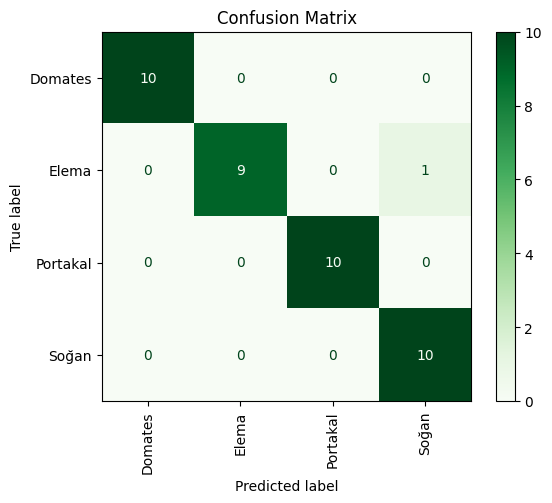

In [36]:
# Tahminler ve Confusion Matrix
predictions = new_model.predict(test_batches, verbose=1)
predicted_classes = predictions.argmax(axis=1)

true_classes = test_batches.classes
class_labels = list(test_batches.class_indices.keys())

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
cm = confusion_matrix(true_classes, predicted_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_labels)

plt.figure(figsize=(10, 10))
disp.plot(xticks_rotation='vertical', cmap='Greens')
plt.title("Confusion Matrix")
plt.show()

#Train-loss eğrileri

Kaybı (Loss) çizimi:

history.history['loss'] → Eğitim kaybı
history.history['val_loss'] → Doğrulama kaybı


Doğruluk (Accuracy) çizimi:

history.history['accuracy'] → Eğitim doğruluğu
history.history['val_accuracy'] → Doğrulama doğruluğu


Hata: 'Accuracy' yerine küçük harf kullan ('accuracy', 'val_accuracy').
Ek ipuçları:

plt.tight_layout() → Grafiklerin taşmasını önler.
plt.show() → Grafikleri görüntüler.

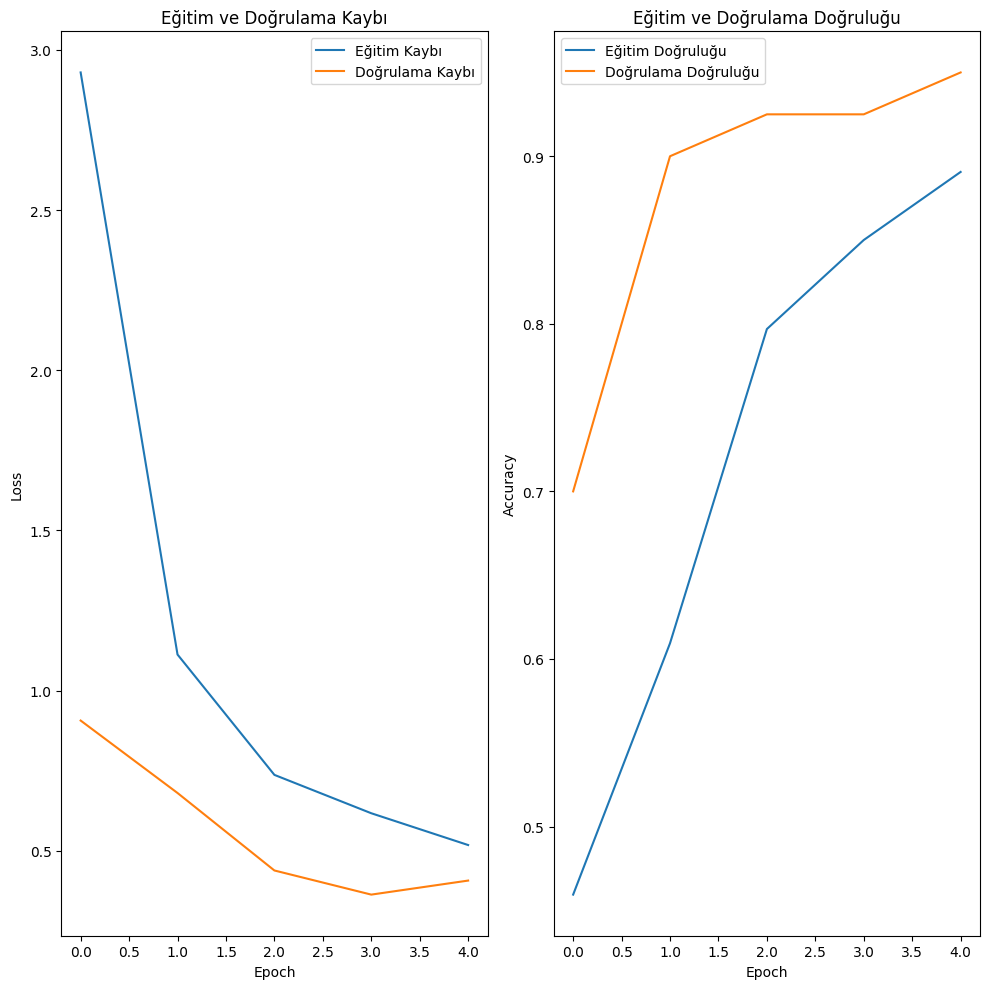

In [38]:
# Eğitim ve doğrulama doğruluğu / kaybı grafikleri

plt.figure(figsize=(10, 10))

# Kayıp (Loss)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Eğitim Kaybı')
plt.plot(history.history['val_loss'], label='Doğrulama Kaybı')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Eğitim ve Doğrulama Kaybı')
plt.legend()

# Doğruluk (Accuracy)
plt.subplot(1, 2, 2)
plt.plot(history.history['Accuracy'], label='Eğitim Doğruluğu')
plt.plot(history.history['val_Accuracy'], label='Doğrulama Doğruluğu')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Eğitim ve Doğrulama Doğruluğu')
plt.legend()

plt.tight_layout()
plt.show()

In [49]:
# En iyi ağırlıkları yükle
new_model.load_weights('signlanguage_model.keras')

#Kendi verini test et


In [72]:
class_indices = test_batches.class_indices  # {'class_name': index}
lass_indices = test_batches.class_indices
class_labels = list(class_indices.keys())
list(class_indices.keys())

print("Class Indices:", class_indices)

Class Indices: {'Domates': 0, 'Elema': 1, 'Portakal': 2, 'Soğan': 3}


Saving portakal test2.webp to portakal test2 (1).webp


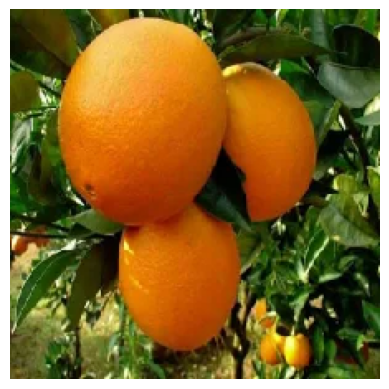

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 653ms/step

Tahmin edilen sınıf: Portakal
Olasılıklar: [[0.14236394 0.27587786 0.4274886  0.1542696 ]]


In [75]:
# Kullanıcıdan resim yükle

# Kullanıcıdan resim yükle
from google.colab import files
from keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt

uploaded = files.upload()  # bilgisayardan resim yükle

# Yüklenen dosya adını bul
img_path = list(uploaded.keys())[0]

# Resmi yükle ve işle
img = image.load_img(img_path, target_size=(224, 224))
plt.imshow(img)
plt.axis('off')
plt.show()

img_array = image.img_to_array(img)
img_array = img_array.astype('float32') / 255.0
img_array = np.expand_dims(img_array, axis=0)

# Tahmin yap
prediction = new_model.predict(img_array)
class_indices = np.argmax(prediction)

print("\nTahmin edilen sınıf:", class_labels[class_indices])
print("Olasılıklar:", prediction)

# **Sonuç**

Transfer öğrenme yaklaşımıyla VGG16 mimarisi kullanılarak Domates, Elma, Portakal ve Soğan sınıflarını sınıflandırmaya yönelik geliştirilen model, test verisi üzerinde %97.5 doğruluk oranı elde etmiştir. Karışıklık matrisi incelendiğinde Domates, Portakal ve Soğan sınıflarının tamamının doğru tahmin edildiği (10/10) görülürken, Elma sınıfında yalnızca bir örnek yanlış sınıflandırılmış ve Soğan olarak tahmin edilmiştir. Bu sonuçlar, modelin genel olarak yüksek performans gösterdiğini, ancak Elma ve Soğan arasında küçük bir karışıklık bulunduğunu ortaya koymaktadır. Görsel benzerlikler veya sınırlı veri miktarı bu hatanın nedeni olabilir. Genel olarak, model güvenilir bir performans sergilemekte olup, veri artırma ve VGG16’nın daha derin katmanlarının ince ayarı ile doğruluk daha da artırılabilir.

# reference:

Uğuz, S., & Uysal, N. (2021). Classification of olive leaf diseases using deep convolutional neural networks. Neural computing and applications, 33(9), 4133-4149.

UĞUZ, S., ŞİKAROĞLU, G., & KAYAALP, K. Recent Advances in CNN Technique Application for Greenhouse Plant.

Malik, A., Vaidya, G., Jagota, V., Eswaran, S., Sirohi, A., Batra, I., ... & Asenso, E. (2022). Design and evaluation of a hybrid technique for detecting sunflower leaf disease using deep learning approach. Journal of Food Quality, 2022(1), 9211700.

Mascarenhas, S., & Agarwal, M. (2021, November). A comparison between VGG16, VGG19 and ResNet50 architecture frameworks for Image Classification. In 2021 International conference on disruptive technologies for multi-disciplinary research and applications (CENTCON) (Vol. 1, pp. 96-99). IEEE.

Albashish, D., Al-Sayyed, R., Abdullah, A., Ryalat, M. H., & Almansour, N. A. (2021, July). Deep CNN model based on VGG16 for breast cancer classification. In 2021 International conference on information technology (ICIT) (pp. 805-810). IEEE.

Tammina, S. (2019). Transfer learning using vgg-16 with deep convolutional neural network for classifying images. International Journal of Scientific and Research Publications (IJSRP), 9(10), 143-150.